In [1]:
from dataclasses import dataclass

import cv2
import cv2 as cv
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

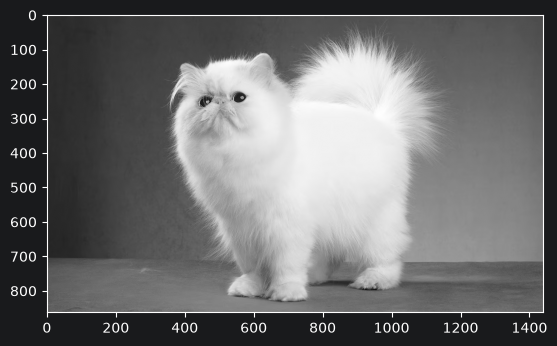

In [2]:
img_path = p.IMAGE_ASSETS / "cat1.png "

img = cv.imread(img_path)

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure()
plt.imshow(img_gray, cmap='gray')

In [3]:
@dataclass(frozen=True, slots=True)
class AdaptiveThreshMethods:
    methods = [cv.ADAPTIVE_THRESH_MEAN_C, cv.ADAPTIVE_THRESH_GAUSSIAN_C]
    names = ["mean", "gaussian"]


In [4]:
maxValue = 255
blockSize = 7
offsetC = 2

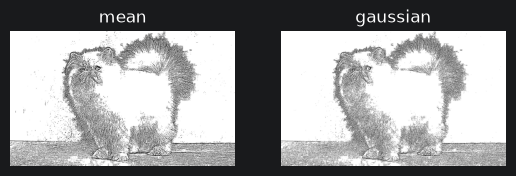

In [5]:
plt.figure()

for i in range(len(AdaptiveThreshMethods.methods)):
    plt.subplot(221 + i)
    plt.title(AdaptiveThreshMethods.names[i])
    threshold = cv.adaptiveThreshold(img_gray, maxValue, AdaptiveThreshMethods.methods[i], cv2.THRESH_BINARY, blockSize, offsetC)
    plt.imshow(threshold, cmap='gray')
    plt.axis("off")

In [6]:
class TrackbarNames:
    METHOD: str = "method"
    OFFSET_C: str = "offset_c"
    BLOCK_SIZE: str = "block_size"

In [7]:
def thresholding_callback(value):
    pass

In [8]:
window_name = "Adaptive Thresholding"
cv.namedWindow(window_name)
h ,w  = img_gray.shape
cv.resizeWindow(window_name, w, h)

cv.createTrackbar(TrackbarNames.METHOD, window_name, 0, len(AdaptiveThreshMethods.methods), thresholding_callback)
cv.createTrackbar(TrackbarNames.BLOCK_SIZE, window_name, 3, 99, thresholding_callback)
cv.setTrackbarMin(TrackbarNames.BLOCK_SIZE, window_name, 3)
cv.createTrackbar(TrackbarNames.OFFSET_C, window_name, 1, 99, thresholding_callback)

while True:
    if cv.waitKey(1) == ord("q"):
        break

    method = cv.getTrackbarPos(TrackbarNames.METHOD, window_name) - 1
    block_size = cv.getTrackbarPos(TrackbarNames.BLOCK_SIZE, window_name)

    if block_size % 2 == 0:
        block_size = block_size + 1
        cv.setTrackbarPos(TrackbarNames.BLOCK_SIZE, window_name, block_size)

    offset = cv.getTrackbarPos(TrackbarNames.OFFSET_C, window_name)

    if method < 0:
        thresholded = img_gray
    else:
        thresholded = cv.adaptiveThreshold(img_gray, maxValue, AdaptiveThreshMethods.methods[method], cv.THRESH_BINARY, block_size, offset)

    cv.imshow(window_name, thresholded)

cv.destroyAllWindows()